# ❤️ Heart Disease Prediction using Machine Learning

## Project Overview

Heart disease is one of the leading causes of death worldwide. Early prediction can help healthcare professionals identify high-risk patients and take preventive measures.

In this project, we perform Exploratory Data Analysis (EDA) on the UCI Heart Disease dataset to understand the relationships between patient characteristics and the presence of heart disease. Later, we will build and evaluate multiple machine learning models to predict whether a patient is likely to have heart disease.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

## Load the Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mragpavank/heart-diseaseuci/heart.csv')
df.shape

(303, 14)

## Dataset Overview

In [3]:
# Basic structure
print("Shape:", df.shape)
df.head()   # As,for sex column 1=male, 0=female

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
# Column info and dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


## Statistical Summary

In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Data Quality Assessment & Cleaning

In [6]:
# Null check
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
# Duplicate check
df.duplicated().sum()

np.int64(1)

In [8]:
# Target balance
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [9]:
# Quick sanity check on known quirky columns in this dataset
print("ca unique values:", sorted(df['ca'].unique()))
print("thal unique values:", sorted(df['thal'].unique()))

ca unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
thal unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [10]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("New Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())

New Shape: (302, 14)
Duplicate rows: 0


## Data Cleaning

The dataset contains:
- No missing values.
- One duplicate row, which was removed.
- The dataset is now clean and ready for exploratory data analysis (EDA).

## Exploratory Data Analysis (EDA)

### Distribution of Heart Disease Cases

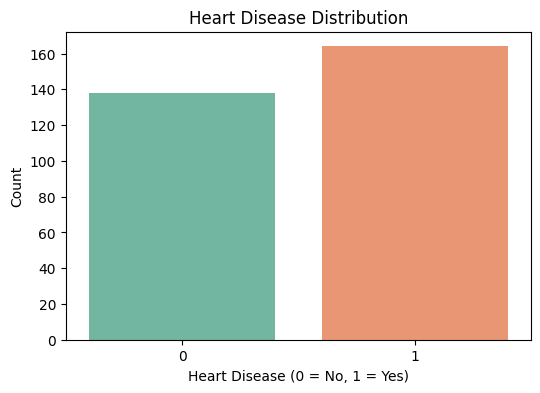

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x='target', data=df, palette='Set2')

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

### Observation

- The dataset contains both patients with and without heart disease.
- The class distribution is relatively balanced, with no severe class imbalance.

### Insight

A balanced target distribution is beneficial for classification tasks because machine learning models are less likely to become biased toward one class. This improves the reliability of model evaluation.

### Age Distribution

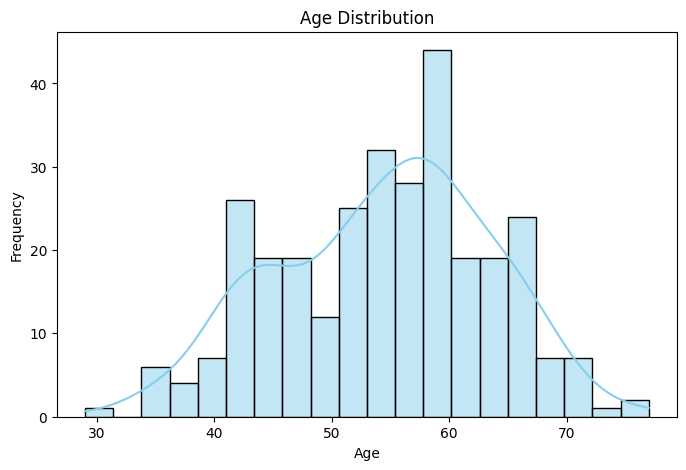

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20, kde=True, color='skyblue')

plt.title("Age Distribution")

plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Observation

- The age of patients is distributed across a wide range.
- Most patients fall within the middle-age to older-age groups.
- The distribution appears reasonably smooth without extreme outliers.

### Insight

Since heart disease risk generally increases with age, age is expected to be an important predictor in the machine learning model. However, age alone is unlikely to determine the presence of heart disease.

### Correlation Heatmap

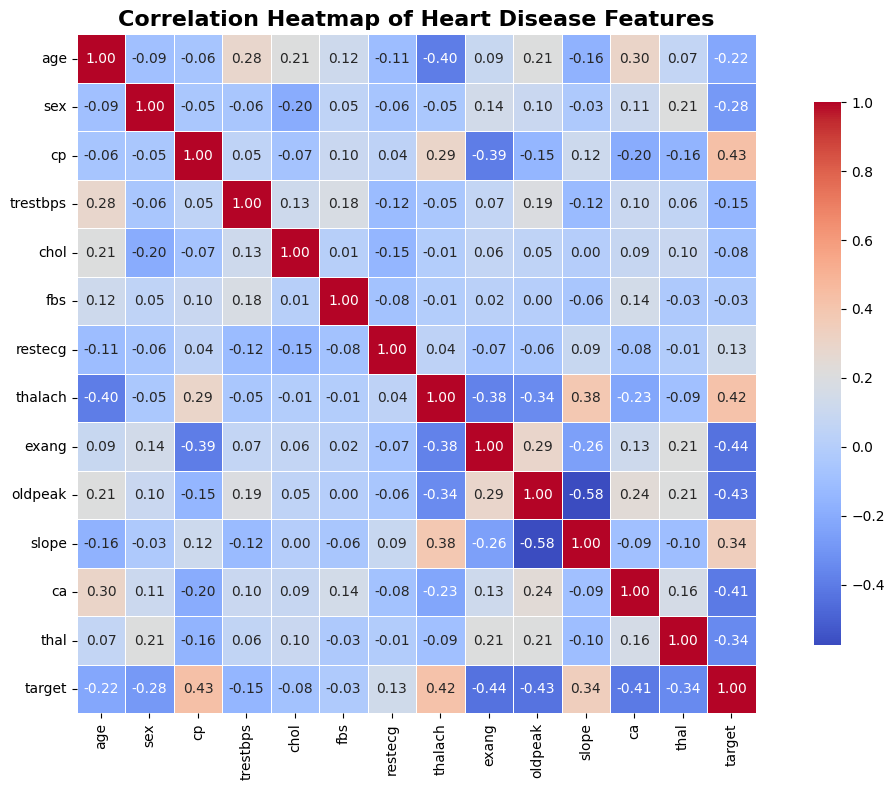

In [13]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",              
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap of Heart Disease Features",
          fontsize=16,
          fontweight="bold")

plt.tight_layout()
plt.show()

### Observation

- The heatmap displays the correlation between all numerical features.
- Most variables show weak to moderate correlations with one another.
- Some features have stronger relationships with the target variable than others.

### Insight

Features such as chest pain type (`cp`), maximum heart rate (`thalach`), exercise-induced angina (`exang`), oldpeak, and the number of major vessels (`ca`) appear to have stronger relationships with heart disease. These variables are likely to contribute significantly to predictive modeling.

### Distribution of Patients by Gender

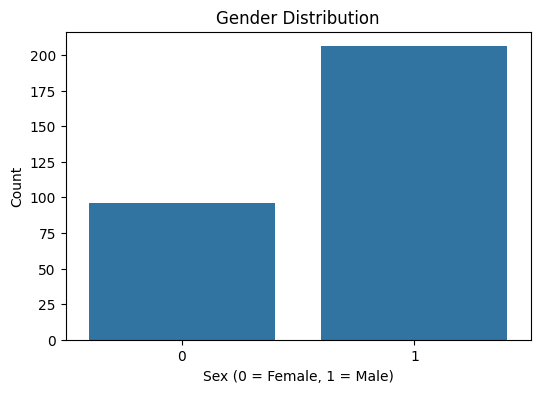

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x='sex', data=df)

plt.title("Gender Distribution")
plt.xlabel("Sex (0 = Female, 1 = Male)")
plt.ylabel("Count")

plt.show()

### Observation

- The dataset contains both male and female patients.
- Male patients represent a larger proportion of the dataset than female patients.

### Insight

The imbalance in gender distribution should be considered when interpreting results. Although more male patients are present, this does not necessarily imply that gender alone determines the risk of heart disease.

### Heart Disease by Gender

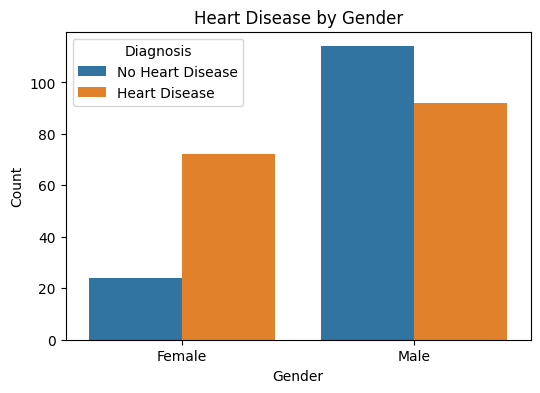

In [15]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='sex', hue='target', data=df)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Female', 'Male'])

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['No Heart Disease', 'Heart Disease'], title='Diagnosis')

plt.title("Heart Disease by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

### Observation

- Heart disease cases are observed in both male and female patients.
- Due to the larger number of male patients in the dataset, more heart disease cases are also observed among males.

### Insight

Gender may influence the occurrence of heart disease, but it should be interpreted alongside other clinical features. Combining multiple predictors generally produces better predictive performance than relying on gender alone.

### Chest Pain Type vs Heart Disease

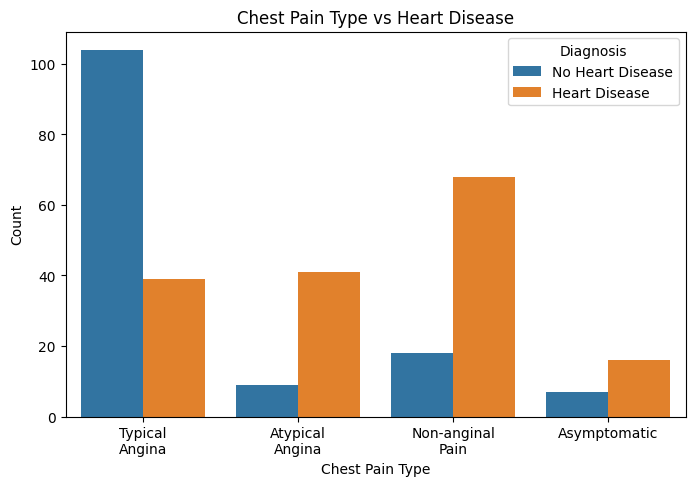

In [16]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x='cp', hue='target', data=df)

# Rename x-axis labels
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels([
    'Typical\nAngina',
    'Atypical\nAngina',
    'Non-anginal\nPain',
    'Asymptomatic'
])

# Rename legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['No Heart Disease', 'Heart Disease'], title='Diagnosis')

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")

plt.show()

### Observation

- The frequency of heart disease varies across different chest pain categories.
- Some chest pain types are associated with noticeably higher numbers of heart disease cases than others.

### Insight

Chest pain type appears to be one of the most informative clinical features in the dataset. This suggests that it is likely to have strong predictive power in machine learning models for heart disease detection.

## Cholesterol Distribution

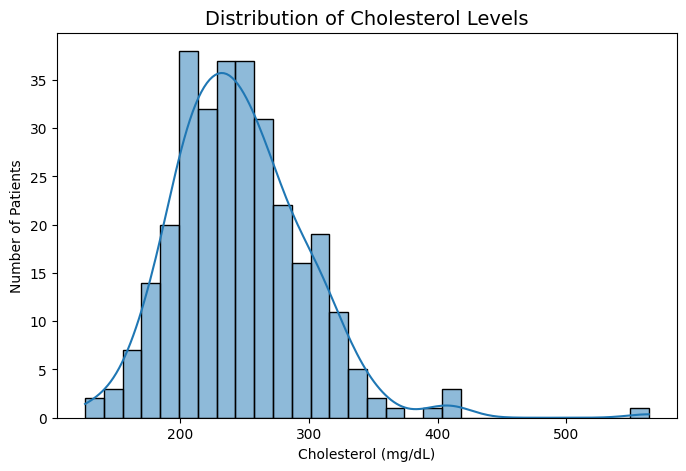

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="chol",
    bins=30,
    kde=True
)

plt.title("Distribution of Cholesterol Levels", fontsize=14)
plt.xlabel("Cholesterol (mg/dL)")
plt.ylabel("Number of Patients")

plt.show()

### Observation

- The cholesterol levels are concentrated between **200 and 300 mg/dL**.
- The distribution is **slightly right-skewed**, with a few patients having very high cholesterol levels.
- A small number of potential outliers are present above **400 mg/dL**.

### Insights

- Most patients in the dataset have cholesterol levels within a moderate range.
- The presence of high cholesterol outliers suggests that some patients may have a higher cardiovascular risk.
- Since cholesterol is a well-known risk factor for heart disease, this feature is expected to contribute to the predictive model.

## Resting Blood Pressure Distribution

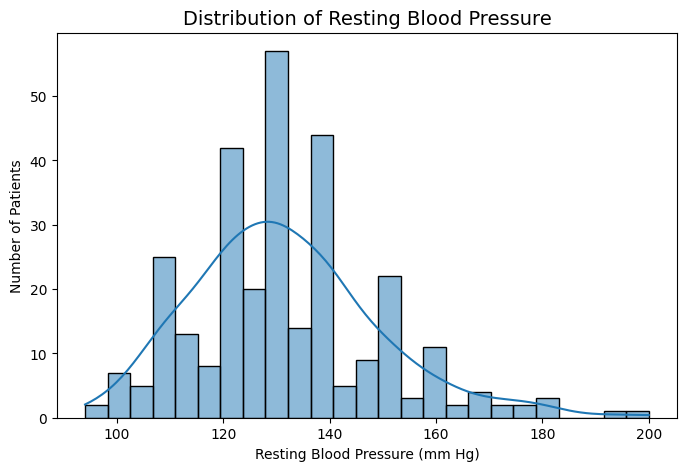

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="trestbps",
    bins=25,
    kde=True
)

plt.title("Distribution of Resting Blood Pressure", fontsize=14)
plt.xlabel("Resting Blood Pressure (mm Hg)")
plt.ylabel("Number of Patients")

plt.show()

### Observation

- Most patients have resting blood pressure between **120 and 140 mm Hg**.
- The distribution is **slightly right-skewed**, with a few patients having higher blood pressure values.
- A small number of patients have resting blood pressure above **170 mm Hg**, indicating potential outliers.

### Insights

- The majority of patients fall within the normal to moderately elevated blood pressure range.
- A few patients exhibit significantly higher resting blood pressure, which may indicate hypertension.
- Since high blood pressure is a major risk factor for cardiovascular diseases, this feature is likely to have predictive importance in the heart disease classification model.

## Maximum Heart Rate Distribution

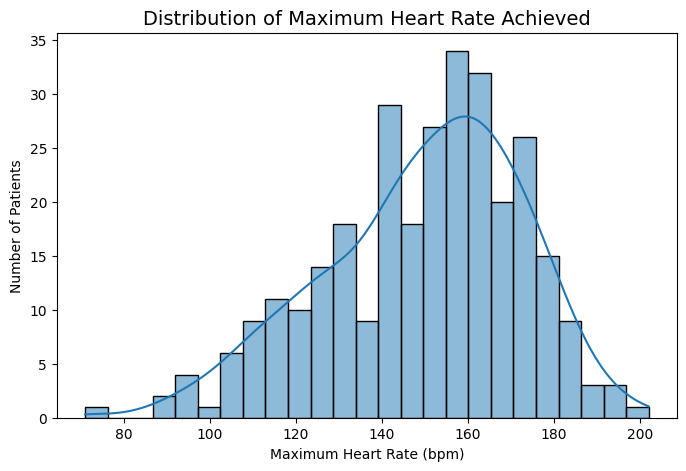

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="thalach",
    bins=25,
    kde=True
)

plt.title("Distribution of Maximum Heart Rate Achieved", fontsize=14)
plt.xlabel("Maximum Heart Rate (bpm)")
plt.ylabel("Number of Patients")

plt.show()

### Observation

- Most patients achieved a maximum heart rate between **140 and 170 bpm**.
- The distribution is **slightly left-skewed**, indicating that a larger number of patients reached higher maximum heart rates.
- Only a few patients recorded a maximum heart rate below **100 bpm**, making them potential low-end outliers.

### Insights

- The dataset is dominated by patients with moderate to high exercise capacity.
- Patients with lower maximum heart rates may have reduced cardiovascular fitness or underlying heart conditions.
- Since maximum heart rate reflects the heart's response to physical activity, this feature is expected to be one of the most influential predictors in the heart disease prediction model.

## Age Distribution by Heart Disease Status

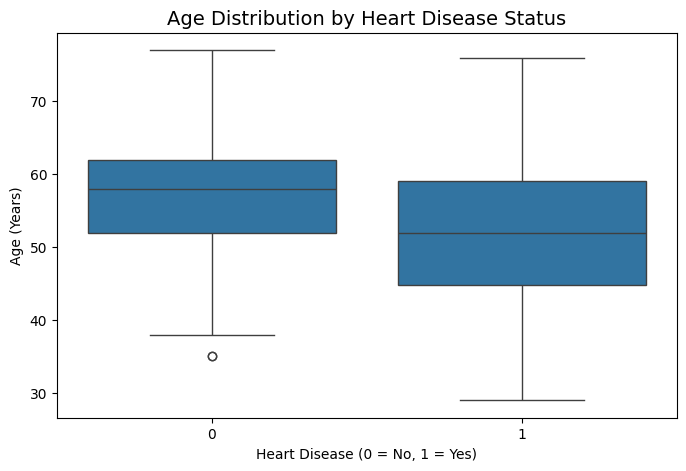

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="target",
    y="age"
)

plt.title("Age Distribution by Heart Disease Status", fontsize=14)
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Age (Years)")

plt.show()

### Observation

- Patients with heart disease generally appear to be older than those without heart disease.
- The age distribution for both groups overlaps, indicating that heart disease is present across different age groups.
- A few outliers are visible in both categories, representing unusually young or old patients.

### Insights

- Age is one of the strongest non-modifiable risk factors for cardiovascular disease.
- As people age, the risk of developing heart-related conditions generally increases due to changes in blood vessels, heart muscles, and other physiological factors.
- Although age alone cannot determine whether a patient has heart disease, it provides valuable information when combined with other clinical features such as cholesterol, blood pressure, and maximum heart rate.

## Oldpeak Distribution by Heart Disease Status

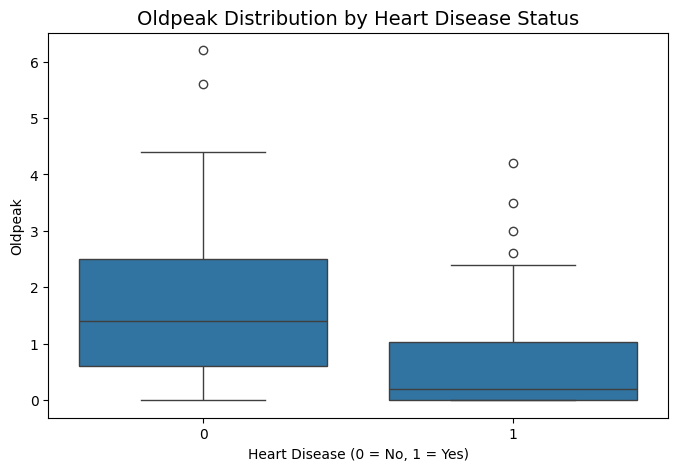

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="target",
    y="oldpeak"
)

plt.title("Oldpeak Distribution by Heart Disease Status", fontsize=14)
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Oldpeak")

plt.show()

### Observation

- Patients with heart disease generally show higher Oldpeak values compared to patients without heart disease.
- The heart disease group exhibits greater variability, with a wider spread of Oldpeak values.
- Several outliers are present, indicating that some patients experienced significantly higher ST depression during exercise.

### Insights

- Oldpeak measures the degree of ST depression during exercise, which reflects how the heart performs under physical stress.
- Higher Oldpeak values may indicate reduced blood flow to the heart muscle, making this feature clinically relevant for detecting heart disease.
- The noticeable difference between the two groups suggests that Oldpeak is likely to be one of the most informative features for predicting heart disease.

## Outlier Analysis

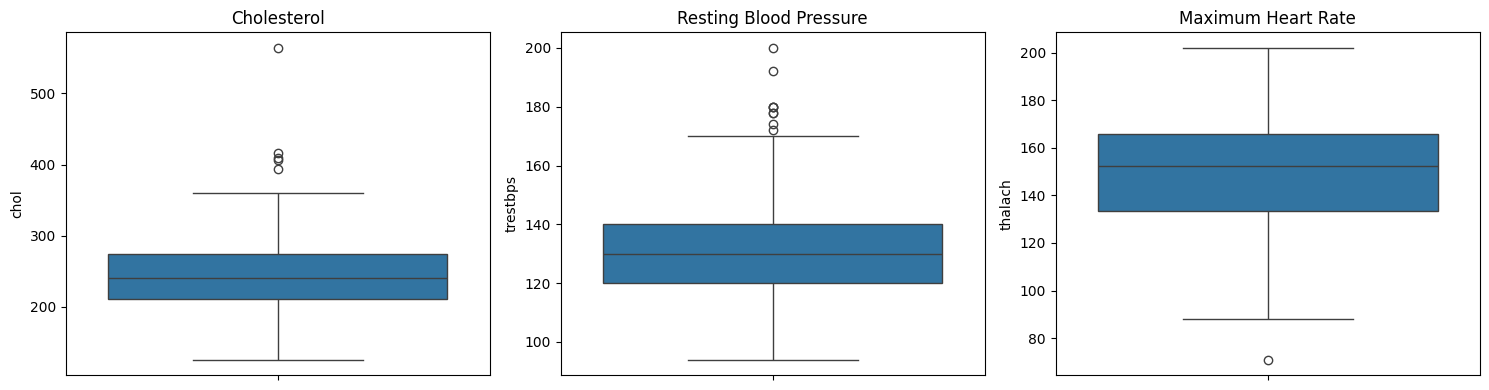

In [22]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.boxplot(y=df["chol"])
plt.title("Cholesterol")

plt.subplot(1, 3, 2)
sns.boxplot(y=df["trestbps"])
plt.title("Resting Blood Pressure")

plt.subplot(1, 3, 3)
sns.boxplot(y=df["thalach"])
plt.title("Maximum Heart Rate")

plt.tight_layout()
plt.show()

### Observation

- Cholesterol (`chol`) contains several high-value outliers.
- Resting Blood Pressure (`trestbps`) also shows a few elevated observations.
- Maximum Heart Rate (`thalach`) has comparatively fewer outliers and a more compact distribution.

### Insights

- The detected outliers may represent patients with genuine medical abnormalities rather than data entry errors.
- Since this is a healthcare dataset, extreme values can carry important clinical information and should not be removed without careful investigation.
- Outlier analysis provides a better understanding of the data distribution and helps determine whether additional preprocessing, such as capping or transformation, is required before model training.

## Feature Correlation with Heart Disease

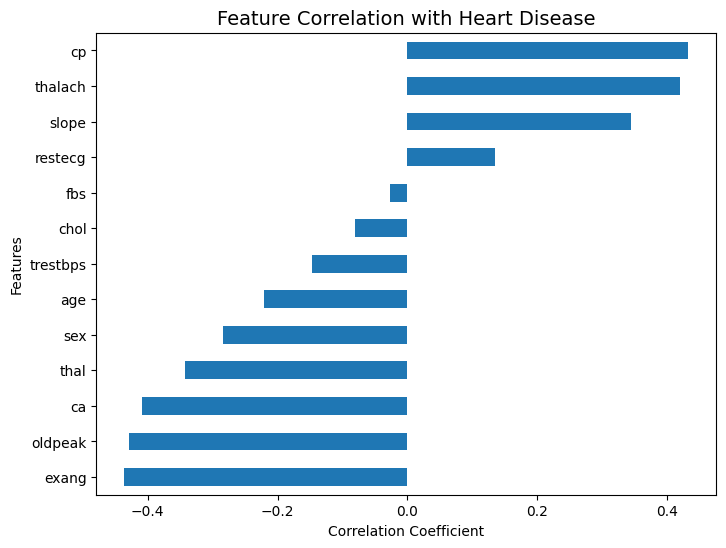

In [23]:
correlation = (
    df.corr(numeric_only=True)["target"]
      .drop("target")
      .sort_values()
)

plt.figure(figsize=(8, 6))

correlation.plot(kind="barh")

plt.title("Feature Correlation with Heart Disease", fontsize=14)
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")

plt.show()

In [24]:
print(df["ca"].value_counts())
print(df["thal"].value_counts())

ca
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64
thal
2    165
3    117
1     18
0      2
Name: count, dtype: int64


## Verifying Invalid Values

In [25]:
print("ca value counts:")
print(df["ca"].value_counts().sort_index())

print("\nthal value counts:")
print(df["thal"].value_counts().sort_index())

ca value counts:
ca
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64

thal value counts:
thal
0      2
1     18
2    165
3    117
Name: count, dtype: int64


In [26]:
df[(df["ca"] == 4) | (df["thal"] == 0)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
48,53,0,2,128,216,0,0,115,0,0.0,2,0,0,1
92,52,1,2,138,223,0,1,169,0,0.0,2,4,2,1
158,58,1,1,125,220,0,1,144,0,0.4,1,4,3,1
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
251,43,1,0,132,247,1,0,143,1,0.1,1,4,3,0
281,52,1,0,128,204,1,1,156,1,1.0,1,0,0,0
